In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("insurance.csv")

# See first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,"$16,884.92"
1,18,male,33.770,1,no,southeast,"$1,725.55"
2,28,male,33.000,3,no,southeast,"$4,449.46"
3,33,male,22.705,0,no,northwest,"$21,984.47"
4,32,male,28.880,0,no,northwest,"$3,866.86"


In [2]:
df.shape

(1338, 7)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 106.8 KB


In [4]:
df.describe()

,age,bmi,children
count,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918
std,14.049960,6.098187,1.205493
min,18.000000,15.960000,0.000000
25%,27.000000,26.296250,0.000000
50%,39.000000,30.400000,1.000000
75%,51.000000,34.693750,2.000000
max,64.000000,53.130000,5.000000


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

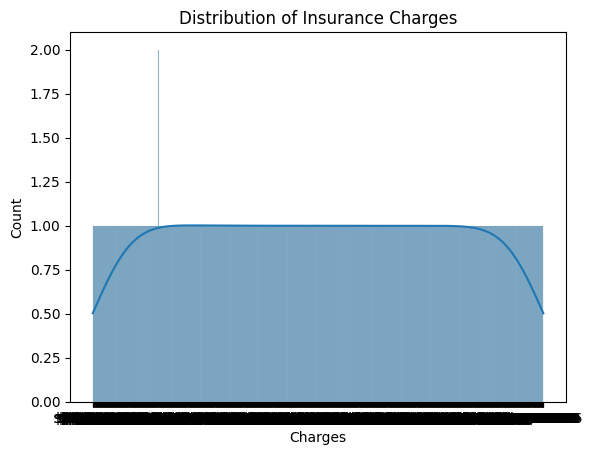

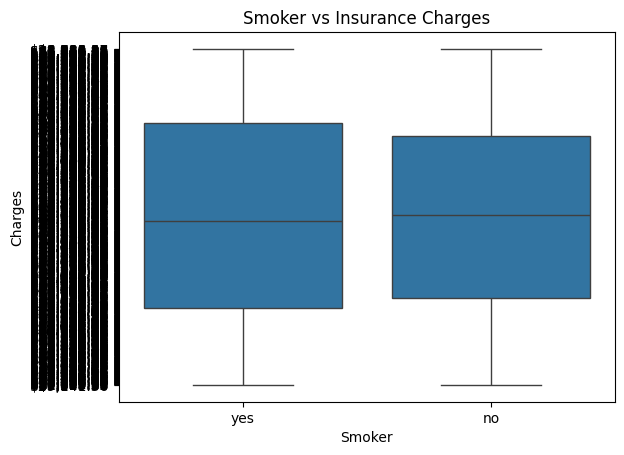

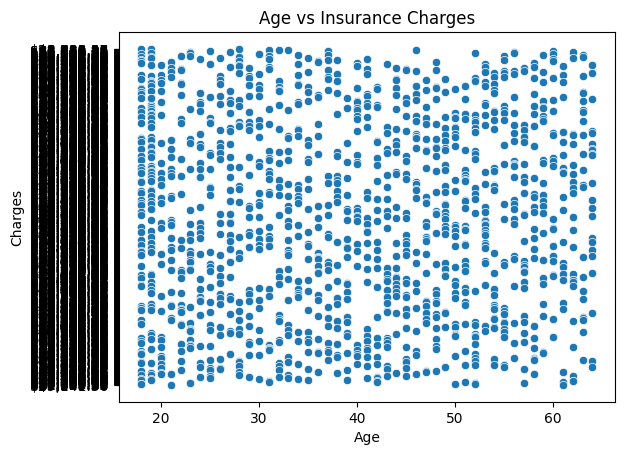

In [6]:
# ================================
# 1️⃣ Distribution of Insurance Charges
# ================================

# Histogram shows how charges are distributed
# kde=True adds a smooth curve to show the shape of distribution

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")  # Title of the graph
plt.xlabel("Charges")                           # X-axis label
plt.ylabel("Count")                             # Y-axis label
plt.show()                                      # Display the plot


# Observation:
# Most people have lower charges.
# A small number of people have very high charges.
# The distribution is right-skewed.



# ================================
# 2️⃣ Smoker vs Insurance Charges
# ================================

# Boxplot compares insurance charges between smokers and non-smokers
# x-axis: smoker category (yes/no)
# y-axis: insurance charges

sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Smoker vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()


# Observation:
# Smokers have significantly higher insurance charges.
# Smoking is a strong predictor for insurance cost.



# ================================
# 3️⃣ Age vs Insurance Charges
# ================================

# Scatterplot shows relationship between age and insurance charges
# Each dot represents one person

sns.scatterplot(x="age", y="charges", data=df)

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()


# Observation:
# Charges tend to increase as age increases.
# There appears to be a positive relationship between age and charges.

In [7]:
# ================================
# Convert Categorical Variables using One-Hot Encoding
# ================================

df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,"charges_$1,131.51","charges_$1,135.94",...,"charges_$9,866.30","charges_$9,869.81","charges_$9,872.70","charges_$9,875.68","charges_$9,877.61","charges_$9,880.07","charges_$9,910.36","charges_$9,957.72","charges_$9,964.06","charges_$9,991.04"
0,19,27.900,0,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,18,33.770,1,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,28,33.000,3,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,33,22.705,0,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,32,28.880,0,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
# ================================
# Define Features (X) and Target (y)
# ================================

X = df_encoded.drop("charges", axis=1)  # All columns except charges
y = df_encoded["charges"]               # Only charges column

KeyError: "['charges'] not found in axis"

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# test_size=0.2 means 20% data for testing
# random_state ensures same split every time

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_test.shape

In [ ]:
X_train.shape

In [ ]:
# =====================================
# Train Linear Regression Model
# =====================================

from sklearn.linear_model import LinearRegression

# Create model object
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)

In [ ]:
# =====================================
# Make Predictions on Test Data
# =====================================

y_pred = model.predict(X_test)

In [ ]:
# =====================================
# Evaluate Model Performance
# =====================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

In [ ]:
print("Intercept:", model.intercept_)

In [ ]:
# =====================================
# Compare Actual vs Predicted Charges
# =====================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

In [ ]:
# =====================================
# Residual Plot
# =====================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
# =====================================
# Train Random Forest Regressor
# =====================================

from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

In [ ]:
print("Linear Regression R2:", r2)
print("Random Forest R2:", rf_r2)

In [ ]:
# =====================================
# Feature Importance (Random Forest)
# =====================================

import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(8,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

In [ ]:
# =====================================
# Apply Log Transformation to Target
# =====================================

import numpy as np

y_log = np.log(df_encoded["charges"])

In [ ]:
X = df_encoded.drop("charges", axis=1)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [ ]:
# Train Linear Regression on log-transformed target

log_model = LinearRegression()
log_model.fit(X_train_log, y_train_log)

# Predict
log_pred = log_model.predict(X_test_log)

In [ ]:
# Convert log predictions back to original scale

log_pred_exp = np.exp(log_pred)
y_test_exp = np.exp(y_test_log)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

log_mae = mean_absolute_error(y_test_exp, log_pred_exp)
log_rmse = mean_squared_error(y_test_exp, log_pred_exp) ** 0.5
log_r2 = r2_score(y_test_exp, log_pred_exp)

print("Log Linear Regression MAE:", log_mae)
print("Log Linear Regression RMSE:", log_rmse)
print("Log Linear Regression R2:", log_r2)

In [ ]:
# =====================================
# Train Final Random Forest on Full Data
# =====================================

from sklearn.ensemble import RandomForestRegressor
import joblib

X_full = df_encoded.drop("charges", axis=1)
y_full = df_encoded["charges"]

final_model = RandomForestRegressor(random_state=42)
final_model.fit(X_full, y_full)

# Save model
joblib.dump(final_model, "insurance_model.pkl")

print("Model saved successfully!")